In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Multilayer perceptron (MLP) is a fully connected, feedforward neural network architecture. It consists of one input layer, one or more hidden layers, and one output layer. Each layer consists of units (also called neurons, or nodes).

Each unit is connected to every unit in a neighboring layer, hence fully connected. This is why in Keras these layers are called `Dense`. Information flows from left to right, hence feedforward.

<img src=https://i.imgur.com/BMcpMsH.png width="800">

      File "/home/hubert/.local/lib/python3.10/site-packages/jupyter_core/utils/__init__.py", line 182, in ensure_async
        result = await obj
      File "/home/hubert/.local/lib/python3.10/site-packages/jupyter_server/services/contents/filemanager.py", line 755, in get
        raise web.HTTPError(404, "No such file or directory: %s" % path)
    tornado.web.HTTPError: HTTP 404: Not Found (No such file or directory: Week2/W2-DL2-MLP-Student-Notebook.ipynb)
[W 2023-03-08 09:14:34.183 ServerApp] 404 GET /api/contents/Week2/W2-DL2-MLP-Student-Notebook.ipynb?content=0&1678263273346 (615777327d9d479f94db354ddccb1714@145.101.210.13) 93.11ms referer=http://hubert-ubuntu:8888/lab
**Learning objectives**

At the end of this DataLab, you will be able to build MLPs using Keras for the following problem types:

 - Regression
 - Binary classification
 - Multi-class classification
 - Multi-label classification
 
For each type, you will be given a suitable dataset. Then you will:

 - Pre-process the data if needed
 - Create a `Sequential()` model.
 - Compile the model by defining a loss function, an optimizer and the metrics to be calculated.
 - Train the model using the `fit()` method.
 - Test the model using the `predict()` and `evaluate()` methods.
 
 
 **Notebook contents**
 
 1. Regression
 2. Binary classification
 3. Multi-class classification
 4. Multi-label classification
 5. Creative brief

## 1. Regression

**The dataset**

In this task, you will use the diabetes dataset provided by `scikit-learn`.

Please read the dataset documentation before you start:

https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

In [2]:
from sklearn import datasets
diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target
names = diabetes.feature_names
Xy_combined = np.concatenate((X, y[:, np.newaxis]), axis=1)
df = pd.DataFrame(Xy_combined,
                  columns=names + ['disease progression'])
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=0)

In [4]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((296, 10), (146, 10), (296,), (146,))

**Task 1.1**

Build an MLP suitable for the diabetes dataset. Use a `Sequential()` model and `Dense` layers from Keras. You are free to pick any number of hidden layers and any number of units per layer as long as it works.  Use suitable activation functions.

In [5]:
# YOUR CODE HERE #
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

sequential = Sequential()

sequential.add(Dense(128 , input_shape=(10, ), activation='relu'))
sequential.add(Dense(64, activation='relu'))
sequential.add(Dense(32, activation='relu'))
sequential.add(Dense(16, activation='relu'))
sequential.add(Dense(8, activation='relu'))
sequential.add(Dense(4, activation='relu'))
sequential.add(Dense(2, activation='relu'))
sequential.add(Dense(1))


2023-04-04 14:11:35.980510: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-04 14:11:38.069231: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-04 14:11:38.075076: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-04 14:11:42.860793: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2023-04-04 14:11:46.865439: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Do

**Task 1.2**
Using `model.compile()`, compile the model. Select a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [6]:
# YOUR CODE HERE #
sequential.compile(loss='mse', optimizer='adam', metrics=['accuracy'])

**Task 1.3** Using `model.fit()` Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [7]:
# YOUR CODE HERE #
monitor_val_acc = EarlyStopping(monitor='val_loss', 
                       patience=5)

model_checkpoint = ModelCheckpoint('best_model.hdf5', save_best_only = True)

# Train your model and save its history
h_callback = sequential.fit(X_train, y_train, epochs = 1000,
                            validation_data=(X_test, y_test),
                            callbacks=[monitor_val_acc, model_checkpoint])

Epoch 1/1000
10/10 [==============================] - 1s 26ms/step - loss: 29127.7266 - accuracy: 0.0000e+00 - val_loss: 28934.0957 - val_accuracy: 0.0000e+00
Epoch 2/1000
10/10 [==============================] - 0s 4ms/step - loss: 29103.3789 - accuracy: 0.0000e+00 - val_loss: 28895.2715 - val_accuracy: 0.0000e+00
Epoch 3/1000
10/10 [==============================] - 0s 3ms/step - loss: 29046.1211 - accuracy: 0.0000e+00 - val_loss: 28798.2988 - val_accuracy: 0.0000e+00
Epoch 4/1000
10/10 [==============================] - 0s 3ms/step - loss: 28899.2969 - accuracy: 0.0000e+00 - val_loss: 28541.8984 - val_accuracy: 0.0000e+00
Epoch 5/1000
10/10 [==============================] - 0s 4ms/step - loss: 28510.7676 - accuracy: 0.0000e+00 - val_loss: 27871.6035 - val_accuracy: 0.0000e+00
Epoch 6/1000
10/10 [==============================] - 0s 3ms/step - loss: 27528.1074 - accuracy: 0.0000e+00 - val_loss: 26246.4277 - val_accuracy: 0.0000e+00
Epoch 7/1000
10/10 [==============================]

**Task 1.4** Evaluate the model using `model.evaluate()`.

In [8]:
# YOUR CODE HERE #
sequential.evaluate(X_test, y_test)

5/5 [==============================] - 0s 649us/step - loss: 3039.3147 - accuracy: 0.0000e+00


[3039.314697265625, 0.0]

**Task 1.5** Get predictions on `X_test`. Plot `y_test` vs. predictions. On the same plot, plot a $x = y$ line. Think about what this line represents.

5/5 [==============================] - 0s 635us/step


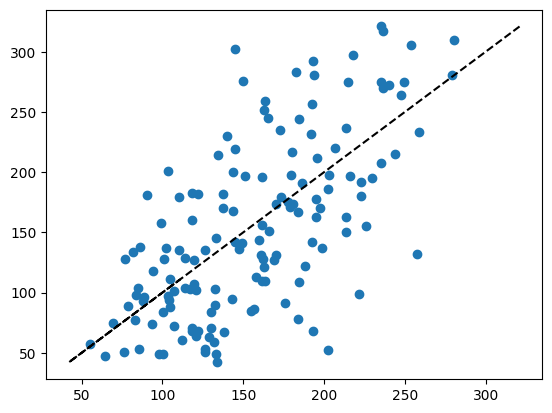

In [9]:
# YOUR CODE HERE #
from matplotlib import pyplot as plt

predicted = sequential.predict(X_test)

plt.scatter(predicted, y_test)
plt.plot(y_test, y_test, 'k--')
plt.show()

## 2. Binary classification

**The dataset**

In this task, you will use the breast cancer dataset provided by `scikit-learn`.

Please read the dataset documentation before you start:

https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

In [10]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
names = list(cancer.feature_names)
Xy_combined = np.concatenate((X, y[:, np.newaxis]), axis=1)
df = pd.DataFrame(Xy_combined,
                  columns=names + ['Benign'])
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Benign
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=0)

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((381, 30), (188, 30), (381,), (188,))

**Task 2.1**

Build an MLP suitable for the breast cancer dataset. Use a `Sequential()` model and `Dense` layers from Keras. You are free to pick any number of hidden layers and any number of units per layer as long as it works. Use suitable activation functions.

In [13]:
# YOUR CODE HERE #
sequential = Sequential()

sequential.add(Dense(128 , input_shape=(30, ), activation='sigmoid'))
sequential.add(Dense(64, activation='sigmoid'))
sequential.add(Dense(32, activation='sigmoid'))
sequential.add(Dense(16, activation='sigmoid'))
sequential.add(Dense(8, activation='sigmoid'))
sequential.add(Dense(4, activation='sigmoid'))
sequential.add(Dense(2, activation='sigmoid'))
sequential.add(Dense(1))


**Task 2.2**

Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [14]:
# YOUR CODE HERE #
sequential.compile(loss='mse', optimizer='adam', metrics=['accuracy'])

**Task 2.3**

Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [15]:
# YOUR CODE HERE #
monitor_val_acc = EarlyStopping(monitor='val_loss', 
                       patience=5)

model_checkpoint = ModelCheckpoint('best_model.hdf5', save_best_only = True)

# Train your model and save its history
h_callback = sequential.fit(X_train, y_train, epochs = 1000,
                            validation_data=(X_test, y_test),
                            callbacks=[monitor_val_acc, model_checkpoint])


Epoch 1/1000
12/12 [==============================] - 1s 9ms/step - loss: 0.4863 - accuracy: 0.3806 - val_loss: 0.4868 - val_accuracy: 0.3564
Epoch 2/1000
12/12 [==============================] - 0s 3ms/step - loss: 0.4561 - accuracy: 0.3806 - val_loss: 0.4563 - val_accuracy: 0.3564
Epoch 3/1000
12/12 [==============================] - 0s 3ms/step - loss: 0.4281 - accuracy: 0.3806 - val_loss: 0.4280 - val_accuracy: 0.3564
Epoch 4/1000
12/12 [==============================] - 0s 3ms/step - loss: 0.4020 - accuracy: 0.3806 - val_loss: 0.4022 - val_accuracy: 0.3564
Epoch 5/1000
12/12 [==============================] - 0s 3ms/step - loss: 0.3789 - accuracy: 0.3806 - val_loss: 0.3786 - val_accuracy: 0.3564
Epoch 6/1000
12/12 [==============================] - 0s 3ms/step - loss: 0.3573 - accuracy: 0.3806 - val_loss: 0.3580 - val_accuracy: 0.3564
Epoch 7/1000
12/12 [==============================] - 0s 3ms/step - loss: 0.3390 - accuracy: 0.3806 - val_loss: 0.3395 - val_accuracy: 0.3564
Epoch 

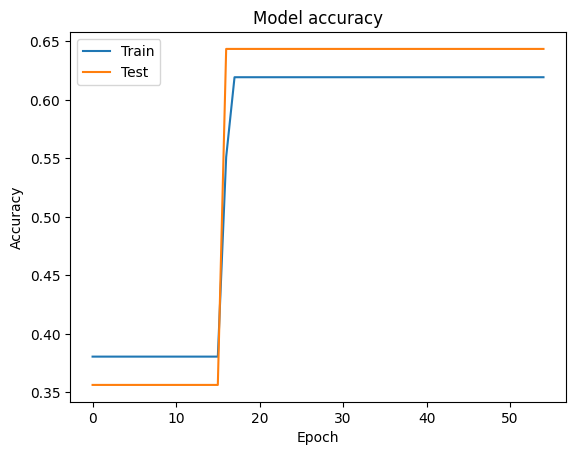

In [16]:
plt.figure()
plt.plot(h_callback.history['accuracy'])
plt.plot(h_callback.history['val_accuracy'])
# Make it pretty
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()

**Task 2.4**

Evaluate the model using `model.evaluate()`.

In [17]:
# YOUR CODE HERE #
sequential.evaluate(X_test,y_test)

6/6 [==============================] - 0s 655us/step - loss: 0.2299 - accuracy: 0.6436


[0.2299317866563797, 0.6436170339584351]

**Task 2.5**

Plot the confusion matrix for your trained model on the test set.

6/6 [==============================] - 0s 553us/step


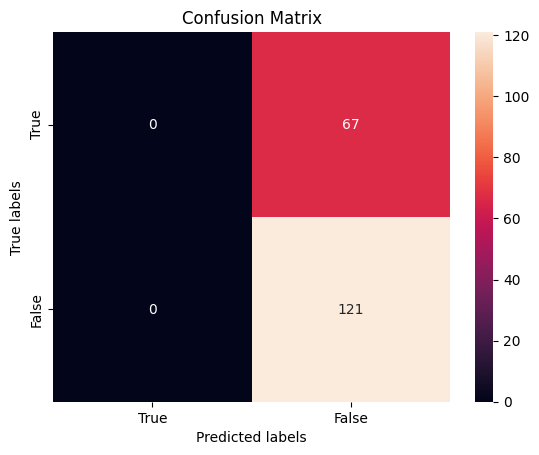

In [18]:
# YOUR CODE HERE #
import seaborn as sns
from sklearn.metrics import confusion_matrix

predicted = np.round_(sequential.predict(X_test))

conf_matrix = confusion_matrix(y_test, predicted)

ax = plt.subplot()
sns.heatmap(conf_matrix, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['True', 'False']); ax.yaxis.set_ticklabels(['True', 'False']);

# Show the plot
plt.show()


## 3. Multi-class classification

**The dataset**

In this task, you will use the MNIST dataset provided by `keras`.

Please read the dataset documentation before you start:

https://keras.io/api/datasets/mnist/

In [19]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 [==============================] - 4s 0us/step


Label: 4


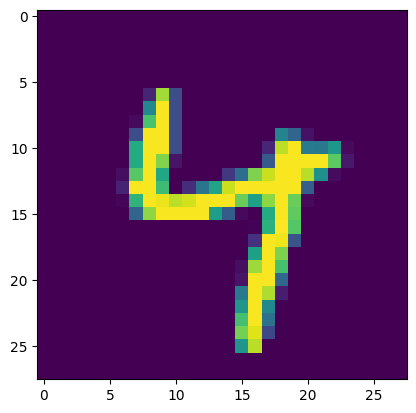

In [20]:
# View random digit
index = np.random.randint(0, 60000)
plt.imshow(X_train[index])
print('Label:', y_train[index])

In [21]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

**Task 3.1**

The MLP architecture you will build is given below. 784 input units, two hidden layers with 30 units each, one output layer with 10 units. Notice that X_train shape and input layer shape are not compatible. Similary, y_train and the output layer shape, are not compatible. Preprocess the data to make them compatible. Same is true for the test data.

<img src=https://i.imgur.com/OFNAslJ.png width="500">



In [22]:
# YOUR CODE HERE #
from tensorflow.keras.utils import to_categorical
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape(10000,784)
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

**Task 3.2**

Build an MLP suitable for the MNIST dataset. Use a `Sequential()` model and `Dense` layers from Keras. Build the architecture shown in Task 3.1 Use suitable activation functions.

In [23]:
# YOUR CODE HERE #
sequential = Sequential()

sequential.add(Dense(30 , input_shape=(784, ), activation='sigmoid'))
sequential.add(Dense(30, activation='sigmoid'))
sequential.add(Dense(10, activation='softmax'))


**Task 3.3**

Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [24]:
# YOUR CODE HERE #
sequential.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

**Task 3.4**

Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [25]:
# YOUR CODE HERE #
monitor_val_acc = EarlyStopping(monitor='val_loss', 
                       patience=5)

model_checkpoint = ModelCheckpoint('best_model.hdf5', save_best_only = True)

# Train your model and save its history
h_callback = sequential.fit(X_train, y_train, epochs = 1000,
                            validation_data=(X_test, y_test),
                            callbacks=[monitor_val_acc, model_checkpoint])

Epoch 1/1000
1875/1875 [==============================] - 2s 681us/step - loss: 1.0467 - accuracy: 0.7296 - val_loss: 0.5642 - val_accuracy: 0.8388
Epoch 2/1000
1875/1875 [==============================] - 1s 621us/step - loss: 0.5323 - accuracy: 0.8426 - val_loss: 0.5032 - val_accuracy: 0.8533
Epoch 3/1000
1875/1875 [==============================] - 1s 602us/step - loss: 0.4520 - accuracy: 0.8636 - val_loss: 0.4512 - val_accuracy: 0.8680
Epoch 4/1000
1875/1875 [==============================] - 1s 589us/step - loss: 0.4489 - accuracy: 0.8627 - val_loss: 0.4333 - val_accuracy: 0.8676
Epoch 5/1000
1875/1875 [==============================] - 1s 610us/step - loss: 0.4227 - accuracy: 0.8708 - val_loss: 0.3766 - val_accuracy: 0.8854
Epoch 6/1000
1875/1875 [==============================] - 1s 606us/step - loss: 0.4013 - accuracy: 0.8781 - val_loss: 0.3613 - val_accuracy: 0.8916
Epoch 7/1000
1875/1875 [==============================] - 1s 604us/step - loss: 0.3743 - accuracy: 0.8872 - val_

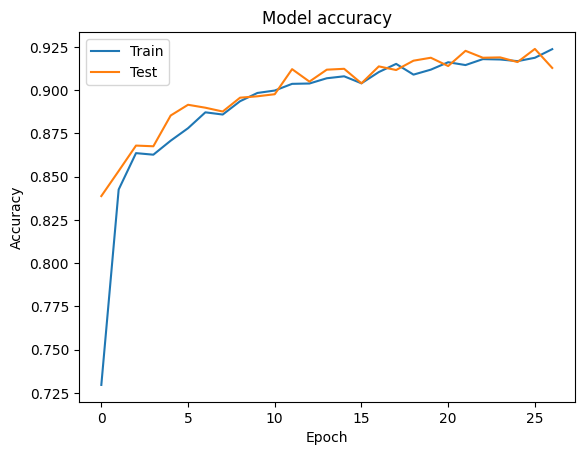

In [26]:
plt.figure()
plt.plot(h_callback.history['accuracy'])
plt.plot(h_callback.history['val_accuracy'])
# Make it pretty
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()

**Task 3.5**

Evaluate the model using `model.evaluate()`.

In [27]:
# YOUR CODE HERE #
sequential.evaluate(X_test, y_test)

313/313 [==============================] - 0s 411us/step - loss: 0.2803 - accuracy: 0.9129


[0.28034767508506775, 0.9128999710083008]

**Bonus: Task 3.6**

Find the worst prediction. If you struggle with this task, try it later.

In [28]:
# YOUR CODE HERE #

## 4. Multi-label classification

**The dataset**

In this task you will use a simulated dataset.

You are given 4 random integers ($x_1, x_2, x_3, x_4$) between -5 and 5 ($x_i \in [-5, 5]$). Your task is to develop an MLP that predicts parity and sign of the product of these four numbers ($x_1 \times x_2 \times x_3 \times x_4$).

**Definitions**

In mathematics, parity is the property of an integer of whether it is even or odd.

In mathematics, the sign of a real number is its property of being either positive, negative, or zero.

**Example**

$x_1=-1, x_2=1, x_3=-3, x_4=-5$

$ product = x_1 \times x_2 \times x_3 \times x_4 = -15$

parity of -15 is `odd` and sign of -15 is `negative`.

**Columns**

$x_i$: Integers between -5 (inclusive) and 5 (inclusive).

Parity column: $x_1 \times x_2 \times x_3 \times x_4$ is even (0) or odd (1).

Sign column: $x_1 \times x_2 \times x_3 \times x_4$ is negative (-1), or zero (0) or positive (1).

|$x_1$|$x_2$|$x_3$|$x_4$|$Parity$|$Sign$|
|:--|:--|:--|:--|:--|:--|
|-2|-4|-1|1|0|-1|
|-3|5|-3|3|1|1|
|-4|-2|5|3|0|1|
|-4|0|-5|0|0|0|
|1|1|2|-4|0|-1|
|-1|1|-3|-5|1|-1|


In [29]:
def simulator(n):
    
    # x_i numbers with shape (n, 4)
    X = np.random.randint(-5, 6, size=(n, 4))

    # product of 4 numbers for each row
    # this will be used to calculate labels
    # but this won't be part of the dataset
    product = np.prod(X, axis=1)

    # label 1
    parity_col = product % 2
    parity_col = parity_col.reshape(-1, 1)

    # label 2
    pos = (product > 0)*1
    neg = (product < 0)*-1
    zero = (product == 0)*0
    sign_col = pos + neg + zero
    sign_col = sign_col.reshape(-1, 1)

    # concatenate columns to create the dataset
    dataset = np.concatenate((X, parity_col, sign_col), axis=1)
    
    return dataset

In [30]:
dataset = simulator(n=10000)

In [31]:
df = pd.DataFrame(dataset, columns=['x_1', 'x_2', 'x_3', 'x_4', 'Parity', 'Sign'])
df.head(10)

,x_1,x_2,x_3,x_4,Parity,Sign
0,-5,-1,-2,-5,0,1
1,-3,-4,1,-5,0,-1
2,1,-4,-2,-5,0,-1
3,-4,-3,1,-3,0,-1
4,-5,0,3,0,0,0
5,-2,0,-3,4,0,0
6,-5,3,0,-2,0,0
7,-3,-1,4,2,0,1
8,2,5,0,3,0,0
9,-3,0,-5,4,0,0


**Task 4.1**

Use the numpy array `dataset` to create `X` and `y`. Preprocess the data if needed.

In [32]:
# YOUR CODE HERE #
from tensorflow.keras.utils import to_categorical
X = df[['x_1', 'x_2', 'x_3', 'x_4']]
y = df[['Parity', 'Sign']]
y = to_categorical(y, num_classes=5)
y = y[:,1,:]

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=0)

In [34]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((6700, 4), (6700, 5), (3300, 4), (3300, 5))

**Task 4.2**

Build a MLP suitable for this simulated dataset. Use a `Sequential()` model and `Dense` layers from Keras. Use suitable activation functions.

In [35]:
# YOUR CODE HERE #
sequential = Sequential()

sequential.add(Dense(64 , input_shape=(4, ), activation='relu'))
sequential.add(Dense(32, activation='relu'))
sequential.add(Dense(16, activation='relu'))
sequential.add(Dense(5, activation='sigmoid'))

**Task 4.3**

Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [36]:
# YOUR CODE HERE #
sequential.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

**Task 4.4**

Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [37]:
# YOUR CODE HERE #
monitor_val_acc = EarlyStopping(monitor='val_loss', 
                       patience=5)

model_checkpoint = ModelCheckpoint('best_model.hdf5', save_best_only = True)

# Train your model and save its history
h_callback = sequential.fit(X_train, y_train, epochs = 1000,
                            validation_data=(X_test, y_test),
                            callbacks=[monitor_val_acc, model_checkpoint])

Epoch 1/1000
210/210 [==============================] - 1s 2ms/step - loss: 1.0047 - accuracy: 0.5569 - val_loss: 0.7653 - val_accuracy: 0.7294
Epoch 2/1000
210/210 [==============================] - 0s 678us/step - loss: 0.6128 - accuracy: 0.8000 - val_loss: 0.4583 - val_accuracy: 0.9024
Epoch 3/1000
210/210 [==============================] - 0s 679us/step - loss: 0.3804 - accuracy: 0.9128 - val_loss: 0.2927 - val_accuracy: 0.9427
Epoch 4/1000
210/210 [==============================] - 0s 691us/step - loss: 0.2445 - accuracy: 0.9481 - val_loss: 0.2381 - val_accuracy: 0.9288
Epoch 5/1000
210/210 [==============================] - 0s 676us/step - loss: 0.1740 - accuracy: 0.9604 - val_loss: 0.1502 - val_accuracy: 0.9685
Epoch 6/1000
210/210 [==============================] - 0s 661us/step - loss: 0.1293 - accuracy: 0.9701 - val_loss: 0.1174 - val_accuracy: 0.9721
Epoch 7/1000
210/210 [==============================] - 0s 691us/step - loss: 0.1000 - accuracy: 0.9769 - val_loss: 0.0938 - v

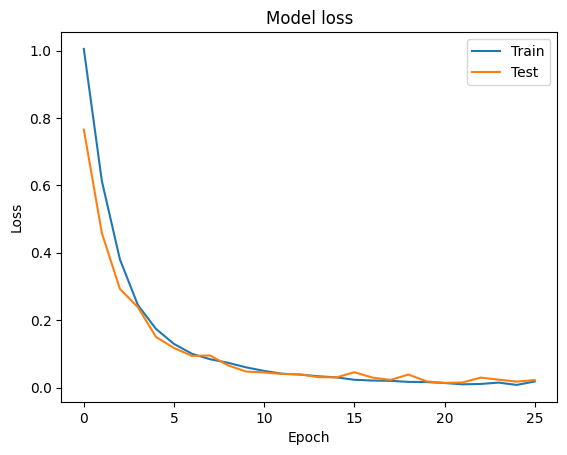

In [38]:
plt.figure()
plt.plot(h_callback.history['loss'])
plt.plot(h_callback.history['val_loss'])
# Make it pretty
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()

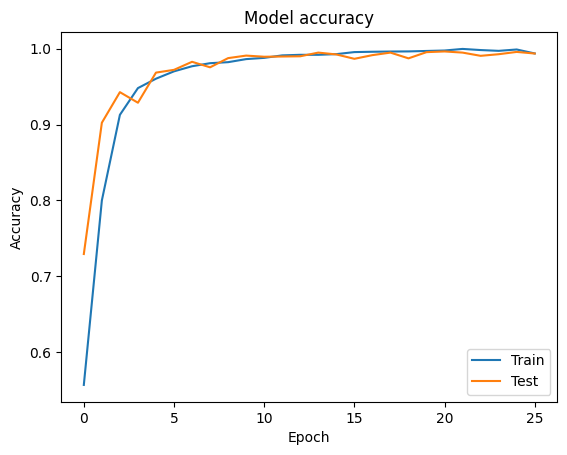

In [39]:
plt.figure()
plt.plot(h_callback.history['accuracy'])
plt.plot(h_callback.history['val_accuracy'])
# Make it pretty
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()

## 5. Creative Brief

Now it is time to apply what you learned to your creative brief. Build, train and test an MLP model with Keras on your creative brief dataset.

In [40]:
import os
import glob
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import normalize


In [41]:
def load_images(paths, labels, max_num_class):
    '''
    
    
    Arguments
        paths: list of directory paths
        lables: list of lables for images in directory
        max_num_class: maximal number of images from directory
    Returns
        images: list of pixelvalues in grayscale
        label: list of labels
    '''
    images = []
    label = []
    for i, path in enumerate(paths):
        count = 0
        for file in glob.glob("../data/" + path + "/*.jpg"):
            if count >= max_num_class:
                break
            images.append(cv2.imread(file, 0))
            label.append(labels[i])
            count += 1
    
    images = np.array(images, dtype=object)
    label = np.array(label, dtype=object)
    
    return images, label

In [42]:
#paths = ["asian man", "asian woman", "black man", "black woman", "white man", "white woman", "wild boar", "wolf", "dear", "fox"]
#labels = [0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
paths = ["0 - human", "1 - animal"]
labels = [0, 1]
X, y = load_images(paths, labels, 820)

In [43]:
X = X.astype("float32")
y = y.astype("bool")

In [44]:
X.shape, y.shape

((1637, 256, 256), (1637,))

In [45]:
X = np.reshape(X, (X.shape[0], X.shape[1]*X.shape[2]))

In [46]:
X.shape, y.shape

((1637, 65536), (1637,))

### normalize

In [47]:
X = normalize(X)


In [48]:
X[0], X[1]

(array([0.00535921, 0.00538802, 0.00541684, ..., 0.00469651, 0.00507108,
        0.00512871], dtype=float32),
 array([0.00105319, 0.00105319, 0.00105319, ..., 0.00692676, 0.00688625,
        0.00688625], dtype=float32))

In [49]:

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=42)

In [50]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1096, 65536), (541, 65536), (1096,), (541,))

In [51]:
sequential = Sequential()

sequential.add(Dense(512, activation='relu'))
sequential.add(Dense(256, activation='relu'))
sequential.add(Dense(64, activation='relu'))
sequential.add(Dropout(0.2))
sequential.add(Dense(1, activation='sigmoid'))

In [52]:
from keras.optimizers import Adam
opt = Adam(lr=0.001)
sequential.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

/home/jupyter/.local/lib/python3.10/site-packages/keras/optimizers/legacy/adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [53]:
monitor_val_acc = EarlyStopping(monitor='val_loss', 
                                patience=10)

model_checkpoint = ModelCheckpoint('best_model.hdf5', save_best_only = True)

# Train your model and save its history
h_callback = sequential.fit(X_train, y_train, epochs = 1000,
                            batch_size = 32,
                            validation_data=(X_test, y_test),
                            callbacks=[monitor_val_acc, model_checkpoint])

Epoch 1/1000
35/35 [==============================] - 9s 234ms/step - loss: 0.6826 - accuracy: 0.5703 - val_loss: 0.6380 - val_accuracy: 0.6322
Epoch 2/1000
35/35 [==============================] - 8s 225ms/step - loss: 0.6241 - accuracy: 0.6524 - val_loss: 0.5684 - val_accuracy: 0.6969
Epoch 3/1000
35/35 [==============================] - 8s 231ms/step - loss: 0.6151 - accuracy: 0.6651 - val_loss: 0.5643 - val_accuracy: 0.6987
Epoch 4/1000
35/35 [==============================] - 8s 226ms/step - loss: 0.5738 - accuracy: 0.6825 - val_loss: 0.5606 - val_accuracy: 0.7024
Epoch 5/1000
35/35 [==============================] - 5s 146ms/step - loss: 0.5604 - accuracy: 0.7181 - val_loss: 0.5725 - val_accuracy: 0.7301
Epoch 6/1000
35/35 [==============================] - 5s 144ms/step - loss: 0.5198 - accuracy: 0.7536 - val_loss: 0.6079 - val_accuracy: 0.6747
Epoch 7/1000
35/35 [==============================] - 5s 144ms/step - loss: 0.5145 - accuracy: 0.7381 - val_loss: 0.5955 - val_accuracy:

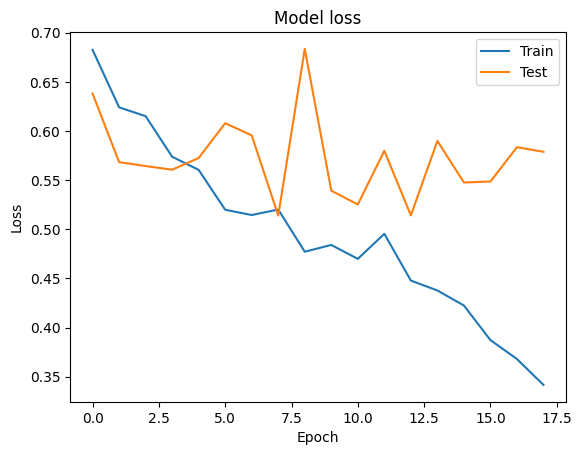

In [54]:
def loss_plotter(H):
    plt.figure()
    plt.plot(H.history['loss'])
    plt.plot(H.history['val_loss'])
    # Make it pretty
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    # YOUR CODE HERE #

loss_plotter(h_callback)

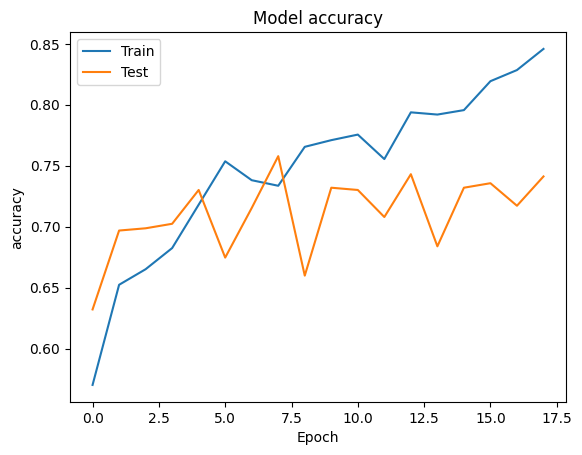

In [55]:
def accuracy_plotter(H):
    # YOUR CODE HERE #
    plt.figure()
    plt.plot(H.history['accuracy'])
    plt.plot(H.history['val_accuracy'])
    # Make it pretty
    plt.title('Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    
accuracy_plotter(h_callback)